# On the R2 Score
## or the Coefficent of Determination

The R2 is defined in Scikit-learn<sub>[1]</sub> and Wikipedia<sub>[2]</sub> as

$$
\begin{array}{rcll}
    R^2 &=& 1 - u/v\\
    u   &=& \sum (y_{true} - y_{pred}~)^2   ~~~&\small \textrm{residual sum of squares}\\
    v   &=& \sum (y_{true} - \mu_{true}~)^2 ~~~&\small \textrm{total sum of squares}
\end{array}
$$

and the quenstion is now, what the range for $R^2$ is? Surely the best score, or theoretical maximum, is one, but what is the theoretical lowest  minimum

$$
    R^2 \in [?, 1]
$$

Scikit-learn declares _"Best possible score is 1.0 and it can be negative [..]"_; lets investigate that via a linear regressor on some pseudo data.

[1] <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html">Scikit-learn: sklearn.metrics.r2_score</a>

[2] <a href="https://en.wikipedia.org/wiki/Coefficient_of_determination">Wikipedia: coefficient_of_determination</a>

In [1]:
%reset -f

def isFloat(z):
    return isinstance(z, (float, np.float64))
        
def Diff(z0, z1):
    for i in [z0, z1]:
        if not isFloat(i):
            raise Exception("expected float-type variable, found type {type(i)}")
    d = np.abs(z0 - z1)
    assert d >= 0
    return d

def Check1DNdType(z0, z1=None):
    if not isinstance(z0, np.ndarray):
        raise Exception(f"wrong type for parameter, expected type ndarray, found {type(z0)}")
    if z0.ndim==1:
        pass
    elif z0.ndim==2:
        if z0.shape[0] <= 0:
            raise Exception("odd array with first shape equal zero")
        if z0.shape[1] != 1:
            raise Exception(f"can only handle 1D arrays for now, found array of shape {z0.shape()}")
    else:
        raise Exception(f"wrong ndim, expected 0 or 1, found ndim {z0.ndim}")
    if z1 is not None:
        Check1DNdType(z1, None)
        if z0.shape[0] != z1.shape[0]:
            raise Exception(f"mismatch in shapes, {z0.shape[0]} != {z1.shape[0]}")
            
print("OK: reset all vars and setup some helper functions..")

OK: reset all vars and setup some helper functions..


OK: regression on some pseudo data, notice the n_sample and noise parameters.


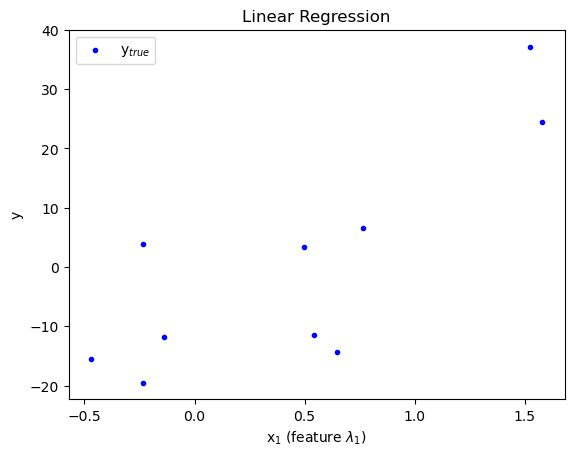

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_regression

X, y_true = make_regression(n_samples=10, n_features=1, noise=10, random_state=42)

def PlotData(X, y_trye, title="Linear Regression"):
    Check1DNdType(X, y_true)
    plt.scatter(X, y_true, color="blue", marker=".", label="y$_{true}$")
    plt.xlabel("x$_1$ (feature $\lambda_1$)")
    plt.ylabel("y")
    plt.legend()
    plt.title(title)

PlotData(X, y_true)

print("OK: regression on some pseudo data, notice the n_sample and noise parameters.")

So, we can easily create some psuedo data with parameters `n_samples` and added `noise` values. There is also a common plot routine for later reuse.

We stricly stick to 1D regression, meaning that the number of features stays at one via the parameter `n_features=1`.


Now, lets do numerical linear regression via the `LinearRegression` in Scikit-learn with a model

$$
    \hat{y} = y_{pred} = \alpha x + \beta
$$

and the noise term modeled by that could be know as the residual, $\epsilon_i$.



OK: lin.reg model  y = 20.77 x + -9.04


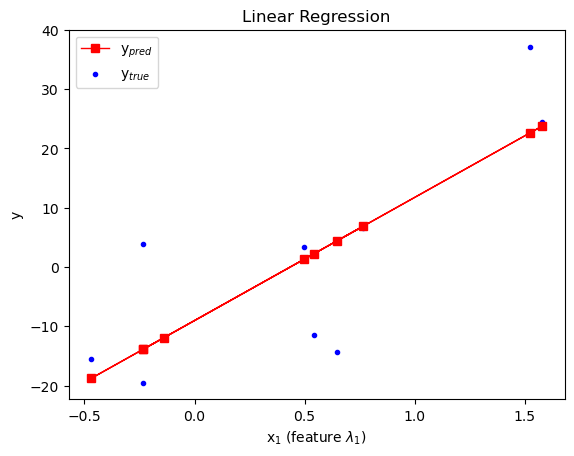

In [3]:
from sklearn import linear_model

reg = linear_model.LinearRegression()
reg.fit(X, y_true)

y_pred = reg.predict(X)

plt.plot(X, y_pred, color="red", marker="s", linewidth=1, label="y$_{pred}$")
PlotData(X, y_true)

a = reg.coef_
b = reg.intercept_

assert len(a)==1, "expected 1D lin reg."
a = a[0]
assert isFloat(a) and isFloat(b)

print(f"OK: lin.reg model  y = {a:.2f} x + {b:.2f}")

### R2 implementation

Lets implement the $R^2$-score function via the definition in Scikit-learn, and test it by comparing it to the default score function on a Scikit-learn linear regressor, that via the documentation can be seen is a $R^2$-scorer.

In [4]:
def My_R2_score(y_true, y_pred):
    Check1DNdType(y_true, y_pred)
    assert y_true.ndim == 1 # try to avoid wrong X as input
    assert y_pred.ndim == 1 # - 
    
    µ = np.mean(y_true)
    u = sum((y_true - y_pred)**2) 
    v = sum((y_true - µ)**2)
    
    if v==0:
        raise Exception("div-by-zero in My_R2_score")

    R2 = 1 - u/v
    assert isFloat(R2) and R2<=1, f"odd value of R2, found {R2}"
    return R2

R2 = reg.score(X, y_true)
my_R2 = My_R2_score(y_true, y_pred)

diff = np.abs(R2 - my_R2)
print(f"OK:\t   R2 = {R2},\n\tmy_R2 = {my_R2},\n\t diff = {diff}")
assert diff < 10E-12

OK:	   R2 = 0.6448166041414749,
	my_R2 = 0.6448166041414747,
	 diff = 2.220446049250313e-16


## The Sample Correlation Coefficient

Now, another correlation dubbed _the sample correlation coefficient_ or _the sample Pearson correlation coefficient_ or just _Pearsons-r_. 

It is defined via slides from the course "Stochastic Modeling".

Lets look at p32 and 33 from "13. Linear Regression" (Lars M.), and implement the method..

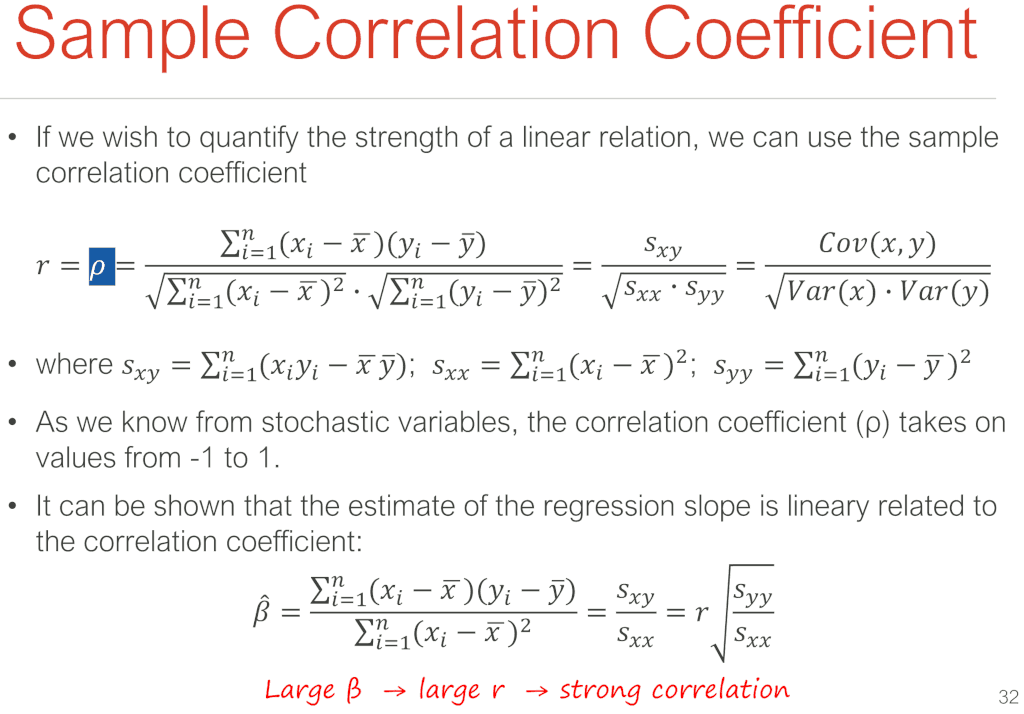

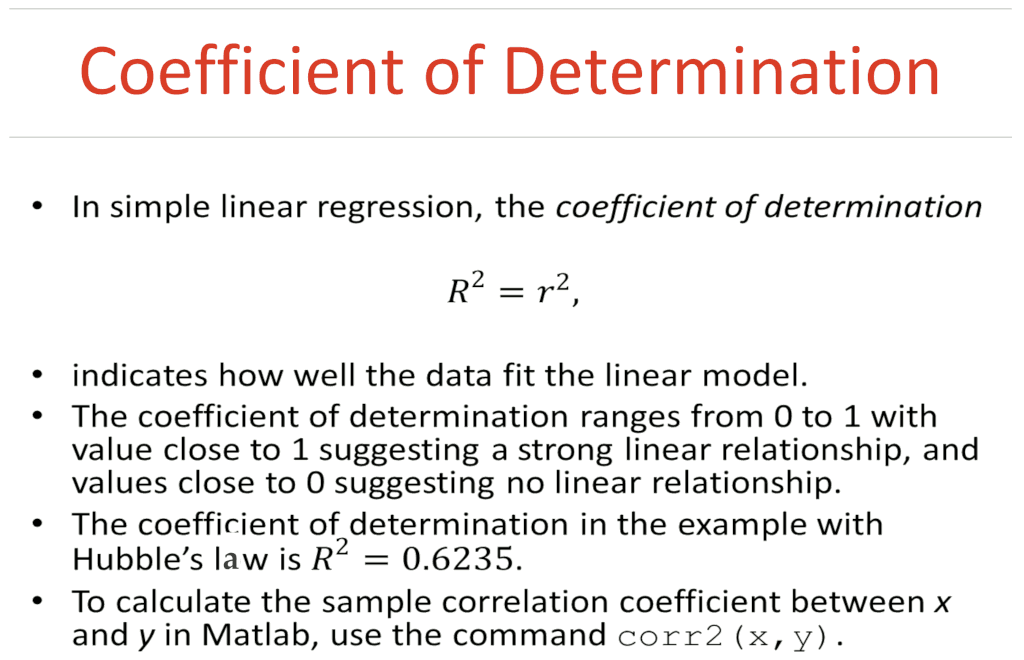

In [5]:
def My_Pearsons_r(X, y, mode="direct"):

    def CheckForDivByZero(d):
        if d==0:
            raise Exception(f"div-by-zero in My_Pearsons_r for mode={mode}")
                           
    Check1DNdType(X, y)
    x = X.flatten()

    if mode == "direct":
        µx = x.mean()
        µy = y.mean()
        
        n=0
        mx=0
        my=0
        for i in range(x.shape[0]):
            xi = x[i]
            yi = y[i]
            n += (xi - µx) * (yi - µy)
        
            mx += (xi - µx)**2
            my += (yi - µy)**2
                
            #print(f"[{i}]: xi={xi}, yi={yi}, mx={mx}, my={my}, n={n}")
        d = ((mx**0.5)*(my**0.5))
        CheckForDivByZero(d)
        my_r = n / d
    elif mode == "covar":
        σx = x.std()
        σy = y.std()
        # cov = np.cov(X.flatten(), y) gives the full 2x2 matrix
        cov = (x * y).mean() - x.mean() * y.mean()
        d = σx*σy
        CheckForDivByZero(d)
        my_r = cov / d
    elif mode == "corrcoef":
        my_r = np.corrcoef(X.flatten(), y)
        assert my_r.shape == (2,2)
        eps = 10-9
        assert np.abs(my_r[0, 0] - my_r[1, 1]) < eps
        assert np.abs(my_r[1, 0] - my_r[0, 1]) < eps
        my_r = my_r[1, 0]  
    else:
        raise Exception(f"mode {mode} not supported, use one-of: 'direct', 'covar', 'corrcoef'")
    
    assert isFloat(my_r)
    assert -1 <= my_r <= 1, f"odd value of my_r, found {my_r}"
    
    return my_r

for mode in ["direct", "covar", "corrcoef"]:
    my_r = My_Pearsons_r(X, y_true, mode)
    print(f"OK: my_r[{mode:8s}] = {my_r}")

OK: my_r[direct  ] = 0.8030047348188395
OK: my_r[covar   ] = 0.8030047348188395
OK: my_r[corrcoef] = 0.8030047348188393


In Scikit-learn the sample correlation coefficent can be found via the `r_regression`<sup>[3]</sup> function, or in Scipy via the `pearsonr`<sup>[4]</sup> function. 

So, now we have the names for $r$

* sample sorrelation coefficient
* Pearson correlation coefficient.
* Pearson’s r

and the naming for $R^2$

* $R^2$, R2 or r2 (pronounced R-square)
* coefficent of determination

via the stated definition of $r$ on the slides

$$
    R^2 = (r)^2
$$

Now, test the implementation via `My_Pearsons_r` (for $r$) and `My_R2_score` (for $R^2$) can now be conducted, noting the different naming in the functions parameters for Scikit-learn and Scipy

```
scipy.stats.pearsonr(x, y, .. )

sklearn.feature_selection.r_regression(X, y, .. )

sklearn.metrics.r2_score(y_true, y_pred, .. )

```
For the test we need to take `x=y_true` and `X=y_true` and `y=y_pred`, wiht at note on the possible confusion of `x` and `X` being the from the Design Matrix.


[3] <a href="https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.r_regression.html#sklearn.feature_selection.r_regression">sklearn.feature_selection.r_regression</a>, and notice this is not in the score namespace.

[4] <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html">scipy.stats.pearsonr</a>

In [6]:
from sklearn.feature_selection import r_regression
from scipy.stats import pearsonr

r_r_regression = r_regression(y_true.reshape(-1,1), y_pred)
r_pearsonr     = pearsonr    (y_true,               y_pred)

r = r_r_regression[0]
print(f"r_r_regression = {r_r_regression[0]}")
print(f"r_pearsonr     = {r_pearsonr[0]}")
print(f"my_r           = {my_r}")

diff = np.abs(my_r - r)
print(f"diff           = {diff}")
assert diff < 10E-12

r2 = r**2
print(f"\nr^2            = {r2}")
print(f"R2             = {R2}")

diff = np.abs(r2 - R2)
print(f"diff           = {diff}")
assert diff < 10E-12

print("\nOK: diffs below epsilon")

r_r_regression = 0.8030047348188395
r_pearsonr     = 0.8030047348188395
my_r           = 0.8030047348188393
diff           = 2.220446049250313e-16

r^2            = 0.6448166041414748
R2             = 0.6448166041414749
diff           = 1.1102230246251565e-16

OK: diffs below epsilon


Fitted lin.reg:
	µx = 0.91,
	µy = 373.1,
	 a = 454.16,
	 b = -40.78
TEST: should yield the values from slide:
	µx = 0.91,
	µy = 373.1,
	 a = 453.16,
	 b = -40.78
Hubble:	   r = 0.7896394879353184,
	  r2 = 0.6235305209067518,
 expected_r2 = 0.6235,
	diff = 3.05209067517076e-05

   r2 = 0.6235305209067518
my_R2 = 0.6235305209067517
 diff = 0.02128608323472314


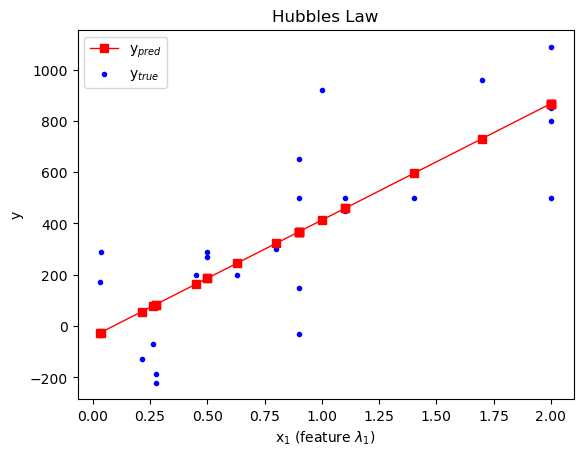

In [7]:
## Dataset Hubbles law

Distance = [0.032,0.034,0.214,0.263,0.275,0.275,0.450,0.500,0.500,0.630,0.800,0.900,0.900,0.900,0.900,1.000,1.100,1.100,1.400,1.700,2.000,2.000,2.000,2.000]
Speed    = [170,290,-130,-70,-185,-220,200,290,270,200,300,-30,650,150,500,920,450,500,500,960,500,850,800,1090]

X = np.array([[i] for i in Distance]) # Scikit-learn algo needs list-of-list like X
y_true = np.array(Speed)

reg = linear_model.LinearRegression()
reg.fit(X, y_true)

y_pred = reg.predict(X)

plt.plot(X, y_pred, color="red", marker="s", linewidth=1, label="y$_{pred}$")
PlotData(X, y_true, "Hubbles Law")

µx = X.mean()
µy = y_true.mean()
a  = reg.coef_[0]
b  = reg.intercept_

print(f"Fitted lin.reg:\n\tµx = {µx:.2f},\n\tµy = {µy:.1f},\n\t a = {a:.2f},\n\t b = {b:.2f}")
print("TEST: should yield the values from slide:\n\tµx = 0.91,\n\tµy = 373.1,\n\t a = 453.16,\n\t b = -40.78")

r = r_regression(y_true.reshape(-1, 1), y_pred)[0]
r2 = r**2
expected_r2 = 0.6235
diff = np.abs(r2 - expected_r2)
print(f"Hubble:\t   r = {r},\n\t  r2 = {r2},\n expected_r2 = {expected_r2},\n\tdiff = {diff}")
assert diff<10-4

my_R2 = My_R2_score(y_true, y_pred)
diff = np.abs(r2 - R2)
print(f"\n   r2 = {r2}")
print(f"my_R2 = {my_R2}")
print(f" diff = {diff}")
assert diff<10-9

[i=0]:
	   r = 0.7896394879353184
	my_r = 0.7896394879353184
	  r2 = 0.6235305209067518
	  R2 = 0.6235305209067517
	diff = 1.1102230246251565e-16
[i=1]:
	   r = 0.7896394879353184
	my_r = 0.7896394879353184
	  r2 = 0.6235305209067518
	  R2 = 0.623522950145269
	diff = 7.57076148272251e-06
[i=10]:
	   r = 0.7896394879353184
	my_r = 0.7896394879353184
	  r2 = 0.6235305209067518
	  R2 = 0.6227734447584948
	diff = 0.0007570761482569299
[i=100]:
	   r = 0.7896394879353184
	my_r = 0.7896394879353184
	  r2 = 0.6235305209067518
	  R2 = 0.5478229060810714
	diff = 0.07570761482568034
[i=1000]:
	   r = 0.789639487935318
	my_r = 0.7896394879353184
	  r2 = 0.6235305209067512
	  R2 = -6.9472309616612735
	diff = 7.570761482568025
[i=10000]:
	   r = 0.789639487935316
	my_r = 0.7896394879353184
	  r2 = 0.6235305209067481
	  R2 = -756.4526177358958
	diff = 757.0761482568026
[i=100000]:
	   r = 0.7896394879353135
	my_r = 0.7896394879353184
	  r2 = 0.6235305209067441
	  R2 = -75706.99129515936
	diff = 7570

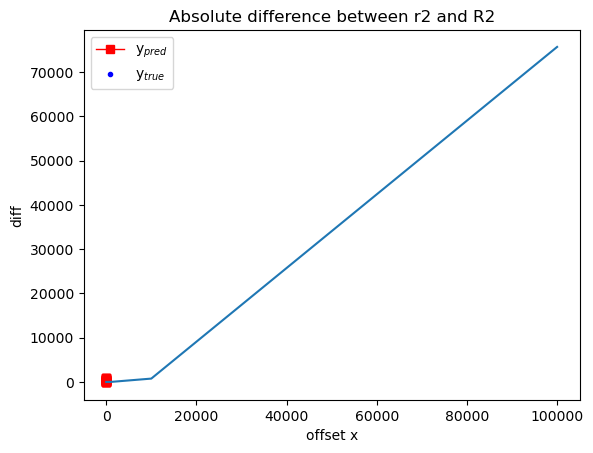

In [8]:
def CompareRs(y_true, y_pred):
    r    = r_regression(y.reshape(-1, 1), y_pred)[0]
    my_r = My_Pearsons_r(y, y_pred)
    
    r2 = r**2
    R2 = My_R2_score(y, y_pred)
    
    diff = np.abs(r2 - R2)
    print(f"[i={i}]:\n\t   r = {r}\n\tmy_r = {my_r}\n\t  r2 = {r2}\n\t  R2 = {R2}\n\tdiff = {diff}")
    
    return r, my_r, r2, R2, diff

xd = []
yd = []
for i in [0, 1, 10, 100, 1000, 10000, 100000]:
    y = y_true + i

    if i==10:
        plt.plot(X, y_pred, color="red", marker="s", linewidth=1, label="y$_{pred}$")
        PlotData(X, y, "Hubbles Law")
    
    _, _, r2, R2, diff = CompareRs(y_true, y_pred)
 
    xd.append(i)
    yd.append([r2, R2, diff])

yd = np.array(yd)
plt.plot(xd, yd[:,2])
plt.xlabel("offset x")
plt.ylabel("diff")
plt.title("Absolute difference between r2 and R2")
print("OK")

Will a mean of `y_true` yield $R^2=0$ as expected?

In [10]:
µy = y_true.mean()

y_pred = np.array([µy for i in y_true]) # a-little weird contructor via a dummy-list-comprehension..

r  = r_regression(y.reshape(-1, 1), y_pred)[0]   
R2 = My_R2_score(y_true, y_pred)    

assert r == 0 and R2 == 0
print(f"OK: for y_pred equal µy:  r = {r},  R2 = {R2}")

OK: for y_pred equal µy:  r = 0.0,  R2 = 0.0
